In [1]:
import os
import math
import pandas as pd
import numpy as np
from tqdm import tqdm
from logger import Logger
import matplotlib.pyplot as plt


import misc
import preprocess_dataset_config as config





In [2]:
processed_images_dataset_path=config.processed_images_dataset_path
raw_endpoint_data_file_path = config.toxicity_endpoints_file_path

target_toxicities = config.target_toxicities
baseline_timepoints = config.baseline_timepoints
target_timepoints = config.target_timepoints
   

toxicity_baseline_columns = config.toxicity_baseline_columns
toxicity_endpoint_columns = config.toxicity_endpoint_columns


image_keys = config.image_keys


dose_info_file_path = config.dose_info_file_path


strata_groups = config.strata_groups

In [3]:
logger = Logger(output_filename = config.logger_txt_output_path)

# Print variables
logger.my_print(f'Starting data preprocessing!')

INFO: Starting data preprocessing!


In [4]:
def load_included_and_included_patients(spreadheet_path):
    """
    Loads the first two sheets in the CITOR_REDCAP file (i.e. the data, and the second tab of excluded patients)
    Joins them and returns one dataframe
    
    Args:
        spreadheet_path: the path to the CITOR_REDCAP excel spreadsheet
    Returns:
        df_dataset: a dataframe of the spreadsheet
    """
    df = []
    for sheet in ['CITOR_REDCAP_clinical_data_impo', 'Nog niet patiënten geexcludeerd']:
        data = pd.read_excel(spreadheet_path, sheet, index_col=None).iloc[:-2]
        data.index = [os.path.basename(sheet)] * len(data)
        df.append(data)

    df_dataset = pd.concat(df)

    try:  df_dataset = df_dataset.drop(['Xerostomia_BSL'], axis=1)  # removes a column from the spreadsheet that breaks everything
    except: pass

    return df_dataset


def trim_dataset_column_names(df):
    """
    Adjusts the column names in the spreadsheet, generally makes them shorter (and nicer)
    Also translates some of them into English.
    
    Args:
        df: a dataframe (the REDCAP data)
    Returns:
        df: the same dataframe, but the column titles are processed and shortened
    """
    df.columns = df.columns.str.replace('HN35_', '')
    df.columns = df.columns.str.replace('DYSFAGIE_UMCGshort', 'Dysphagia')

    df.columns = df.columns.str.replace('UMCG', 'PatientID')
    df.columns = df.columns.str.replace('GESLACHT', 'Sex')
    df.columns = df.columns.str.replace('LEEFTIJD', 'Age')

    return df


def load_dose_info(dose_info_file_path):
    """
    Loads a csv that contains all of the mean doses. 
    Returns a dataframe with only the patientID and (desired) mean dose values for each OAR
    
    Args:
        dose_info_file_path: a path to the csv file that contains all of the (mean) dose info for all of the OARs
    Returns:
        df_dose_means: a dataframe containing only the patientIDs and the desired dose feature columns
        dose_columns: the names of the dose columns kept, as a list of strings
    """
    df_dose = pd.read_csv(dose_info_file_path, delimiter=';', index_col=None, decimal=",")
    df_dose["PatientID"] = [str(item).zfill(config.patient_id_length) for item in df_dose["PatientID"]]  # make sure that the patient IDs are strings of 7 digits (i.e. pad the small numbers with 0's)

    dose_columns = get_dose_column_names(df_dose)  # retrieve the names of the dose info we want to keep
    
    df_dose_means = df_dose[['PatientID'] + dose_columns]  # remove all excess columns

    return df_dose_means, dose_columns


def get_dose_column_names(df_dose):
    """
    Retrieves the names of the dose columns we want to keep
    Does so by seeing in the config file if we've named them explicitly (config.dose_features), or not, and we want to
    scrape the columns of the dose csv file by a certain keyword (config.meandose_target_word), it keeps all of the columns that contain that keyword
    If both are set to None in the config file, then return an empty list. 
    Priority is given to the explict list of names.
    
    Args:
        df_dose: the full dataframe of patient doses (for all OARs)
    Returns:
        dose_column_names: a list of strings, containing the column names we want to keep
    """
    if config.dose_features is not None:            # explicit list of names
        dose_column_names = config.dose_features
    elif config.meandose_target_word is not None:   # scan and keep all that contain the target word (e.g. everything with 'meandose' in it)
        target_word = config.meandose_target_word
        dose_column_names = [x for x in df_dose.columns if target_word in x]
    else:
        dose_column_names = []   # we don't want/need any dose info
    return dose_column_names
   
    


def load_data_spreadsheet(spreadheet_path, use_excluded_patients_sheet=False):
    """
    Loads the CITOR_RECAP spreadsheet, and does some initial preprocessing:
    - opens the file
    - trims down the column names and anglicizes them
    - drops any duplicate patients, converts the 'PatientID' column into strings (and not integers)
    - removes patients that are in the 'exclude_list'
    - removes columns that are not needed (that aren't clinical variables, patient IDs, or (desired) toxicity columns)
    
    Args:
        spreadheet_path: the path to the REDCAP data spreadsheet
        use_excluded_patients_sheet: (optional) whether to also load the excluded patients
    Returns:
        df_dataset: a dataframe with all patients, with all features (clinical, baseline, dose, endpoint), regardless of whether they're missing or not
        dose_columns: names of the dose columns
    """

    if use_excluded_patients_sheet:
        df_dataset = load_included_and_included_patients(spreadheet_path)
    else:
        df_dataset = pd.read_excel(spreadheet_path, index_col=None)

    # adjust the column names
    df_dataset = trim_dataset_column_names(df_dataset)

    # drop duplicate patients and convert that column to a string dtype (also pad the short IDs with zeroes)
    df_dataset.drop_duplicates(subset=['PatientID'], inplace=True, keep='first')
    df_dataset = df_dataset.sort_values(by=['PatientID'])
    df_dataset["PatientID"] = [str(item).zfill(config.patient_id_length) for item in df_dataset["PatientID"]]

    # drop patients that should be excluded (according to the list in the config file)
    df_dataset = df_dataset[~df_dataset['PatientID'].isin(config.exclude_list)]

    # get all of the toxity baseline and endpoint columns to keep
    columns_to_keep = config.main_columns + toxicity_baseline_columns + toxicity_endpoint_columns   # also the clinical columns
    df_dataset = df_dataset[columns_to_keep]

    
    if config.meandose_target_word is not None and config.meandose_target_word is not None:
        # load the file containing all of the RT dose (e.g. mean dose per OAR):
        df_dose_means, dose_columns = load_dose_info(dose_info_file_path)
    
        # merge the doses onto df_dataset, by patientID
        df_dataset = df_dataset.merge(df_dose_means, how='left', on='PatientID')


    return df_dataset, dose_columns







df_dataset, dose_columns = load_data_spreadsheet(raw_endpoint_data_file_path, use_excluded_patients_sheet=False)

In [5]:
##
# 1. Get patients with all 3 image files
# 2. get patients with all 16 segmentations
# 3. get patients that are not missing baselines or endpoints

# 4. find the overlap between those three sets
# 5. make the testing set from that overlap

In [9]:
# def check_segmap_structures(processed_images_dataset_path, logger):
#     """
#     Checks all of the processed segmaps to see if all of the OARs are present (there should be 16 of them, excluding the background=0)
#     Returns a list of patientIDs of the patients that are missing at least 1 structure
#     Also saves a spreadsheet that specifies which structures each of these patients are missing.
    
#     Args:
#         processed_images_dataset_path: path to the folder containing all patients' (preprocessed) image files
#     Returns:
#         patients_with_missing_structs: list of strings, containing the IDs of all patients that are missing at least one structure in their segmentation map
#     """
#     all_patient_folders = next(os.walk(processed_images_dataset_path))[1]
#     all_possible_structures = config.structures_values_to_names

#     df_cols = ["PatientID"] + list(all_possible_structures.values())

#     rows = []
#     logger.my_print("Checking if patient segmenation maps include all 16 structures...")
    

#     for patient_ID in tqdm(all_patient_folders):
#     #for patient_folder in all_patient_folders:
#         segmap_path = os.path.join(os.path.join(processed_images_dataset_path, patient_ID), "segmentation_map.npy")
#         SEGMAP = np.load(segmap_path)[0,:,:,:]
        
        
#         unique_values = np.unique(SEGMAP)[1:]  # ignore the background
#         unique_values_count = len(unique_values)
#         if unique_values_count != 16:
#             logger.my_print(f"Patient {patient_ID} has only {unique_values_count} unique structures.", level='warning')
            
            
#             missing_struct_vals = [1 if x not in unique_values else None for x in all_possible_structures ]

#             row = [patient_ID] + missing_struct_vals
#             rows.append(row)
          
    
#     df_missing_structs = pd.DataFrame(rows, columns=df_cols)
#     df_missing_structs.to_excel(config.missing_structs_save_path, index=None)

#     patients_with_missing_structs = list(df_missing_structs["PatientID"])
#     return patients_with_missing_structs



def all_three_image_inputs_present(path_to_patient_folder, logger):
    """
    Checks if this patient's folder has all three CT, RTDOSE and Segmentation images (one of each)
    
    Args:
        path_to_patient_folder: path to patient's folder, which contains their CT, RTDOSE and segmap npy files
    Returns:
        Bool: true if all three are present, else false
    """
    required_files = set(image_keys)
    file_list = os.listdir(path_to_patient_folder)
    file_names_without_extension = [os.path.splitext(file)[0] for file in file_list]
    files = set(file_names_without_extension)

    if required_files.issubset(files):
        return True
    else:
        logger.my_print(f"{path_to_patient_folder} missing {list(required_files - files)}" , level='warning')
        return False



def check_all_patients_images_complete(processed_images_dataset_path, logger):
    """
    Checks if every patients' folder has all three CT, RTDOSE and segmentation images
    Returns a list of patients that have all three images
    
    Args:
        processed_images_dataset_path: path to the folder containing all patients' (preprocessed) image files
    Returns:
        patients_with_all_images: list of all patientIDs that have all 3 images, that also have all structures in them
    """
    all_patient_folders = next(os.walk(processed_images_dataset_path))[1]

    patients_with_all_images = []
    
    for patient_ID in all_patient_folders:
        patient_folder_path = os.path.join(processed_images_dataset_path, patient_ID)
        
        images_present = all_three_image_inputs_present(patient_folder_path, logger)
        if images_present: 
            patients_with_all_images.append(patient_ID)


    return patients_with_all_images



#processed_images_dataset_path = "//zkh/appdata/RTDicom/Projectline_HNC_modelling/PRI2MA/preprocessed/dataset_full"

patients_with_all_image_files = check_all_patients_images_complete(processed_images_dataset_path, logger=logger)

#patients_with_missing_structs = check_segmap_structures(processed_images_dataset_path, logger)


logger.my_print(f"There are {len(patients_with_all_image_files)} patients with all images files")
#logger.my_print(f"There are {len(patients_with_missing_structs)} patients with missing OAR structures", level='warning')

INFO: There are 1168 patients with all images files


In [10]:
parotis_structures = ['parotis_li', 'parotis_re']
submand_structures = ['submandibularis_li', 'submandibularis_re']
lower_structures = ['crico', 'thyroid']
mandible_structures = ['mandible']
other_structures = ['glotticarea', 'oralcavity_ext', 'supraglottic', 'buccalmucosa_li',
                    'buccalmucosa_re', 'pcm_inf', 'pcm_med', 'pcm_sup', 'esophagus_cerv']
structures_compound_list = [parotis_structures, submand_structures, lower_structures, mandible_structures,
                            other_structures]
structures_uncompound_list = [i for x in structures_compound_list for i in x]

structures_uncompound_list

['parotis_li',
 'parotis_re',
 'submandibularis_li',
 'submandibularis_re',
 'crico',
 'thyroid',
 'mandible',
 'glotticarea',
 'oralcavity_ext',
 'supraglottic',
 'buccalmucosa_li',
 'buccalmucosa_re',
 'pcm_inf',
 'pcm_med',
 'pcm_sup',
 'esophagus_cerv']

In [11]:
def filter_patients_with_missing_values(df_dataset, column_names):
    """
    Finds all patients that do not have None values in specific columns of a dataframe
    Args:
        df_dataset: a dataframe
        column_names: names of the columns to drop rows if they have None values in them
    Returns:
        patient_IDs: list of patientIDs without None values in said columns
    """
    ### PATIENTS WITH NO NULLS FOR ALL TOXICITIES
    df_filtered = df_dataset.copy()
    df_filtered = df_filtered.dropna(subset=['PatientID']  + column_names)  # drop all patients with missing values

    patient_IDs = list(df_filtered['PatientID'])

    return patient_IDs


# get all of the patients that have all endpoints, and the same but for all baseline values
patients_with_complete_endpoints = filter_patients_with_missing_values(df_dataset, toxicity_endpoint_columns)
patients_with_complete_baselines = filter_patients_with_missing_values(df_dataset, toxicity_baseline_columns)
patients_with_complete_doses = filter_patients_with_missing_values(df_dataset, dose_columns)


logger.my_print(f"There are {len(patients_with_complete_endpoints)} patients with all desired toxicity endpoints")
logger.my_print(f"There are {len(patients_with_complete_baselines)} patients with all desired toxicity baselines")
logger.my_print(f"There are {len(patients_with_complete_doses)} patients with all mean doses info")


# find the intersection of that
#patients_with_all_features = set(patients_with_complete_endpoints).intersection(set(patients_with_complete_baselines))
patients_with_baselines_and_doses = set(patients_with_complete_doses).intersection(set(patients_with_complete_baselines))
logger.my_print(f"There are {len(patients_with_baselines_and_doses)} patients with all baselines + doses")
# new: also include doses
patients_with_all_features = set(patients_with_complete_endpoints).intersection(set(patients_with_complete_baselines).intersection(set(patients_with_complete_doses)))


# patients that have all image inputs (and all segmentations)
patients_with_complete_image_inputs = set(patients_with_all_image_files) #- set(patients_with_missing_structs)

INFO: There are 928 patients with all desired toxicity endpoints
INFO: There are 1257 patients with all desired toxicity baselines
INFO: There are 1151 patients with all mean doses info
INFO: There are 1037 patients with all baselines + doses


In [10]:
len(patients_with_all_features)

878

In [12]:
## list of IDs of patients that have all toxicity features and all complete image inputs
everything_present_patients = list(patients_with_all_features.intersection(patients_with_complete_image_inputs))

df_complete_patients = df_dataset[df_dataset['PatientID'].isin(everything_present_patients)]

logger.my_print(f"{len(everything_present_patients)} patients have all input and outputs available")


INFO: 867 patients have all input and outputs available


In [43]:
df = df_complete_patients.copy()
frac = config.test_set_size
stratified_sampling_columns = config.strata_groups
#stratified_sampling_columns = ["CT+C_available", "CT_Artefact", "Loctum2", "Photons"]
#stratified_sampling_columns = toxicity_endpoint_columns

size_testing_set = int(frac * len(df_dataset)) 
#size_testing_set = int(frac * 1168)   # HARDCODED :)
size_as_fraction_of_df = size_testing_set/len(df_complete_patients)


logger.my_print(f"Performing stratified sampling. By: {stratified_sampling_columns}")
logger.my_print(f"Testing set size: {frac}. Number of samples should equal = {size_testing_set}")

seed = 0


df_test = df.groupby(stratified_sampling_columns).apply(lambda x: x.sample(frac=size_as_fraction_of_df, replace=False,
                                                                              random_state=seed))
df_train_val = df.loc[~df.index.isin(df_test.index)]




test_set_length_difference = size_testing_set - len(df_test)



if test_set_length_difference == 0:    # test set is exactly frac % of the full dataset
    pass
elif test_set_length_difference > 0:   # test set is too small, pull some random datapoints from the training set
    logger.my_print(f"Stratified sampling returned too small of a test set ({len(df_test)}). Randomly sampling {test_set_length_difference} samples from the training set.")
    try:
        rows = df_train_val.groupby(stratified_sampling_columns).apply(lambda x: x.sample(n=test_set_length_difference, replace=False, random_state=seed))
    except:
        rows = df_train_val.apply(lambda x: x.sample(n=test_set_length_difference, replace=False, random_state=seed))
    
    rows_index = rows.index
    df_test = pd.concat([df_test, rows])
    df_train_val = df_train_val.drop(rows_index)
    #df_train_val = df_dataset.drop()
    
else:                                  # test set is too large, move some random datapoints to the training set
    test_set_length_difference *= -1
    logger.my_print(f"Stratified sampling returned too large of a test set ({len(df_test)}). Moving {test_set_length_difference} samples back to the training set.")
    try:
        
        rows = df_test.groupby(stratified_sampling_columns).apply(lambda x: x.sample(n=(test_set_length_difference), replace=False, random_state=seed))
    except:
        rows = df_test.apply(lambda x: x.sample(n=test_set_length_difference, replace=False, random_state=seed))

    rows_index = rows.index
    df_train_val = pd.concat([df_train_val, rows])
    df_test = df_test.drop(rows_index)



test_set_patientIDs = list(df_test['PatientID'])
df_train_val =  df_dataset[~df_dataset['PatientID'].isin(test_set_patientIDs)].copy()


INFO: Performing stratified sampling. By: ['CT+C_available', 'CT_Artefact', 'Loctum2', 'Photons', 'Xerostomia_M06', 'Aspiration_M06', 'Sticky_M06', 'Taste_M06', 'Dysphagia_M06']
INFO: Testing set size: 0.2. Number of samples should equal = 285
INFO: Stratified sampling returned too small of a test set (135). Randomly sampling 150 samples from the training set.


In [44]:
def preprocess_clinical_variables(df):
    """
    Normalises age, and encodes tge 'Sex' column into integer values
    Args:
        df: the features dataframe
    Returns:
        df: the same dataframe, but with the Age and Sex columns preprocessed
    """
    # normalise age by dividing by 100
    df['Age'] = df['Age'] / 100
    
    # binary encode Sex
    df['Sex'] = df['Sex'].replace({"Vrouw":int(0), "Man":int(1)})
    df.head(-10)

    return df

def binarise_toxicity_columns(df, toxicity_columns):
    """
    binarises the toxicity columns of a dataframe, and makes new binary-encoded columns for each toxicity level (e.g. "Helemaal niet", "Een beetje", etc), that can be used for the DL model baseline values input
    
    Args:
        df: the features dataframe
        toxicity_columns: the column names for all of the toxicity baselines and endpoints
    Returns:
        df: the same as the input df, but the toxicity columns are now binary, and new binary columns have been added in the format of the baseline input to the DL model
    """

    #value_mapping = {"Helemaal niet":"not_at_all", "Een beetje":"little", "Nogal":"moderate", "Heel erg":"severe"}
    #df = df.replace(value_mapping)

    for tox_col_name in toxicity_columns:
        if "Dysphagia" in tox_col_name:
            dysphagia_mapping = {
                "geen slikklachten/normaal eetpatroon / wel slikklachten, maar kan wel alles eten": "no",
                "geen slikklachten/normaal eetpatroon": "no",
                "alleen gepureerd/zacht voedsel": "yes",
                "wel slikklachten, maar kan wel alles eten": "no",
                "neussonde of PEG, maar nog wel orale intake mogelijk / neussonde of PEG, geen enkele orale intake meer mogelijk": "yes",
                "alleen vloeibaar voedsel, geen sondevoeding": "yes",
                "neussonde of PEG, maar nog wel orale intake mogelijk": "yes",
                "neussonde of PEG, geen enkele orale intake meer mogelijk": "yes",
            }
            df = df.replace(dysphagia_mapping)

        # Binarize the values in 'tox_col_name'
        df_binary_columns = pd.get_dummies(df[tox_col_name], prefix=tox_col_name)
        df_binary_columns = df_binary_columns.astype('Int64')
        #print(df_binarized.head())

        # Concatenate the binarized columns with the original DataFrame
        df = pd.concat([df, df_binary_columns], axis=1)

    # binarise the origincal columns
    value_mapping = {"no":int(0), "yes":int(1)}  ## for dysphagia
    df = df.replace(value_mapping)
    #value_mapping = {"not_at_all":0, "little":0, "moderate":1, "severe":1}
    value_mapping = {"Helemaal niet":int(0), "Een beetje":int(0), "Nogal":int(1), "Heel erg":int(1)}
    df = df.replace(value_mapping)
    
    return df
    

toxicity_columns = toxicity_baseline_columns + toxicity_endpoint_columns

df_test = preprocess_clinical_variables(df_test)  
df_test = binarise_toxicity_columns(df_test, toxicity_columns)  

df_train_val = preprocess_clinical_variables(df_train_val)  
df_train_val = binarise_toxicity_columns(df_train_val, toxicity_columns)

df_dataset = preprocess_clinical_variables(df_dataset)  
df_dataset = binarise_toxicity_columns(df_dataset, toxicity_columns)

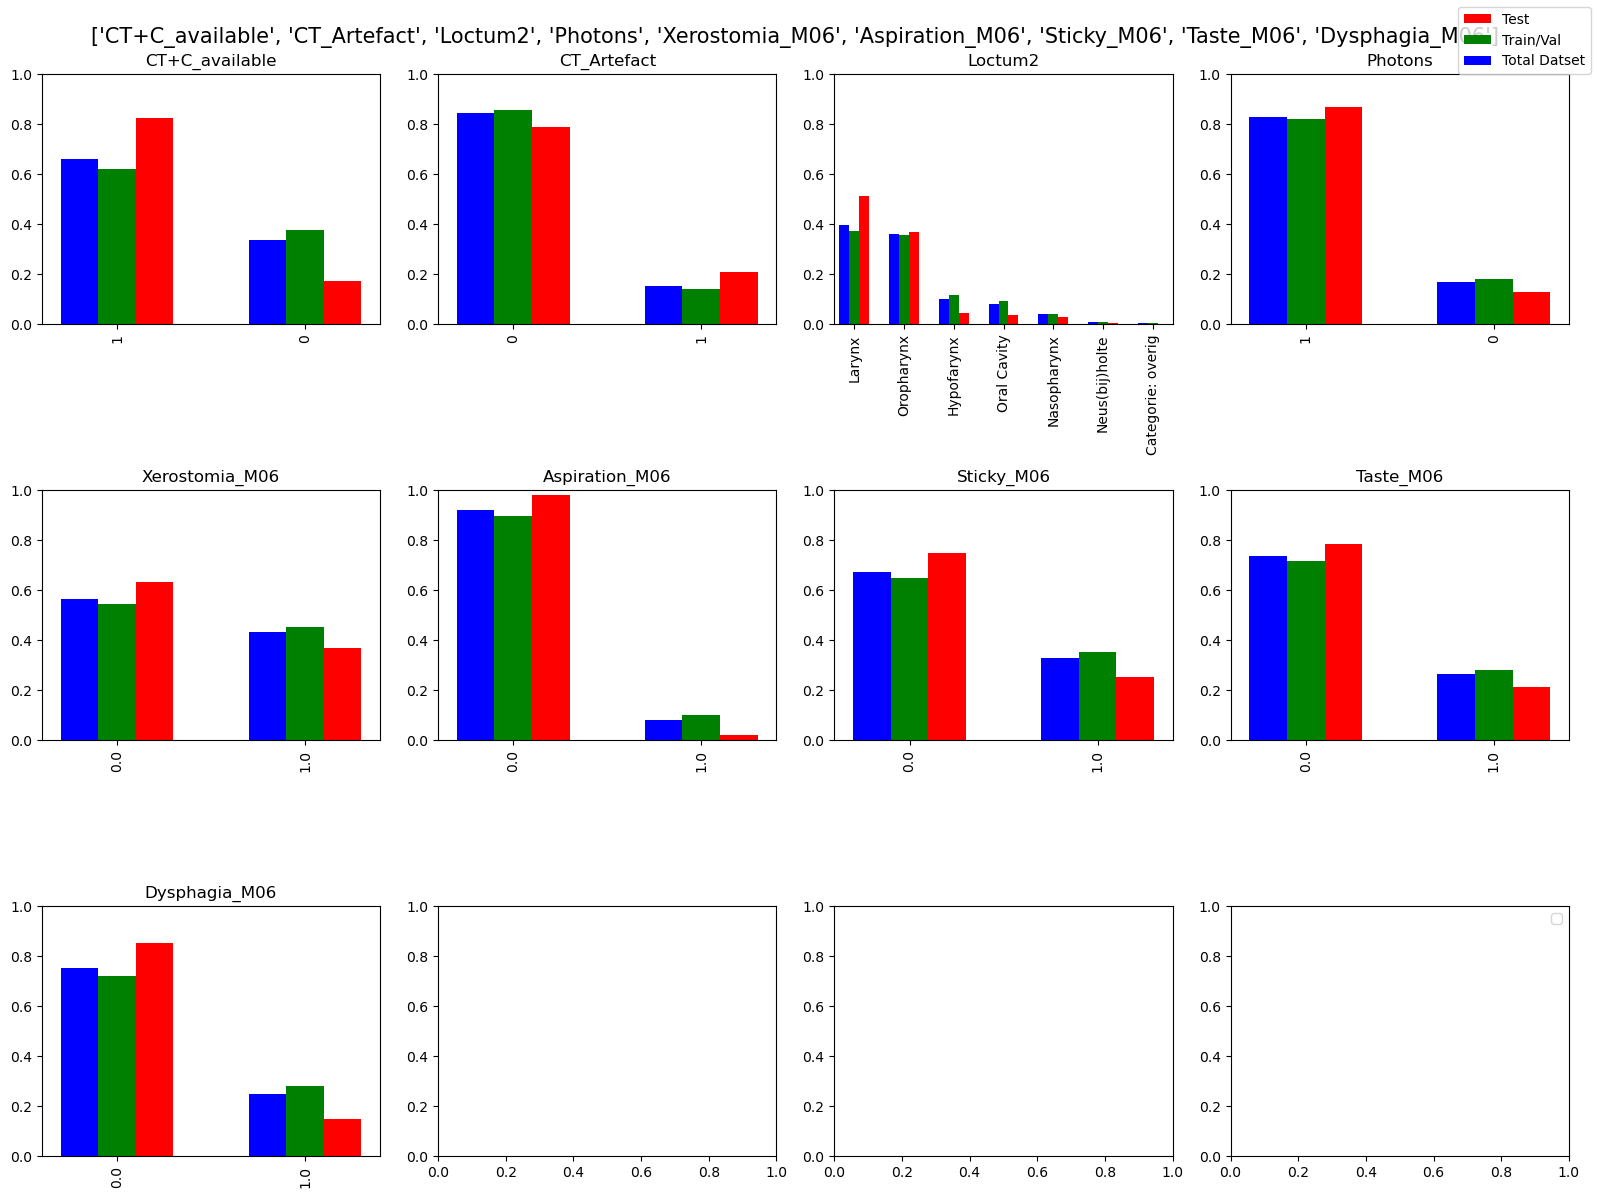

In [45]:
#train_StratColumns["Split"] = "train_val"
#test_StratColumns["Split"] = "test"

#df_plot = pd.concat([train_StratColumns, test_StratColumns])
plotting_columns = config.strata_groups


#df_summary_statistics = pd.DataFrame(columns=["feature", "total_dataset", "training_datset", "testing_dataset"])

cols = 4
rows = math.ceil(len(plotting_columns) / cols)
bar_width = 0.2
normalise = True
colours = ['r', 'g', 'b']
names = ["Test", "Train/Val", "Total Datset"]

fig,ax = plt.subplots(rows,cols,figsize=[4*cols,4*rows])
for i in range(len(plotting_columns)):
    col_name = plotting_columns[i]
    
    [row_idx, col_idx] = [int(i/cols),int(i % cols)]

    ax[row_idx, col_idx].set_title(col_name)

    max_keys = 0

    for j, df in enumerate([df_test, df_train_val, df_dataset]):
        value_counts = df[col_name].value_counts(normalize=normalise)

        if len(value_counts.keys()) > max_keys:
            max_keys = len(value_counts.keys())

        value_counts.plot(kind='bar', ax=ax[row_idx, col_idx], color=colours[j], align='edge', position=j, width=bar_width, label=names[j])
    
    # ascending=i makes it not sort the first feature (train_val and test)
    #df_dataset[col_name].sort_values(ascending=True).value_counts(normalize=normalise, dropna=True).plot(kind='bar', ax=ax[row_idx, col_idx],  color='b', align='edge', position=0, width=bar_width, label="Dataset")
    #df_train_val[col_name].sort_values(ascending=True).value_counts(normalize=normalise, dropna=True).plot(kind='bar', ax=ax[row_idx, col_idx], color='g', align='edge', position=1, width=bar_width, label="Train_Val")
    #df_test[col_name].sort_values(ascending=True).value_counts(normalize=normalise, dropna=True).plot(kind='bar', ax=ax[row_idx, col_idx], color='r', align='edge', position=2, width=bar_width, label="Test")

    ax[row_idx, col_idx].set_xlabel(None)
    ax[row_idx, col_idx].axis(xmin = 0-2*bar_width, xmax=max_keys-1 + 2*bar_width)
    if normalise:
        ax[row_idx, col_idx].axis(ymax=1)

fig.suptitle(stratified_sampling_columns, fontsize=15)
fig.tight_layout()
#fig.suptitle(title, fontsize = 13)
#plt.tight_layout()
#plt.savefig(label_images_save_dir + "/class_value_counts.png")
handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')


plt.legend()
plt.show()

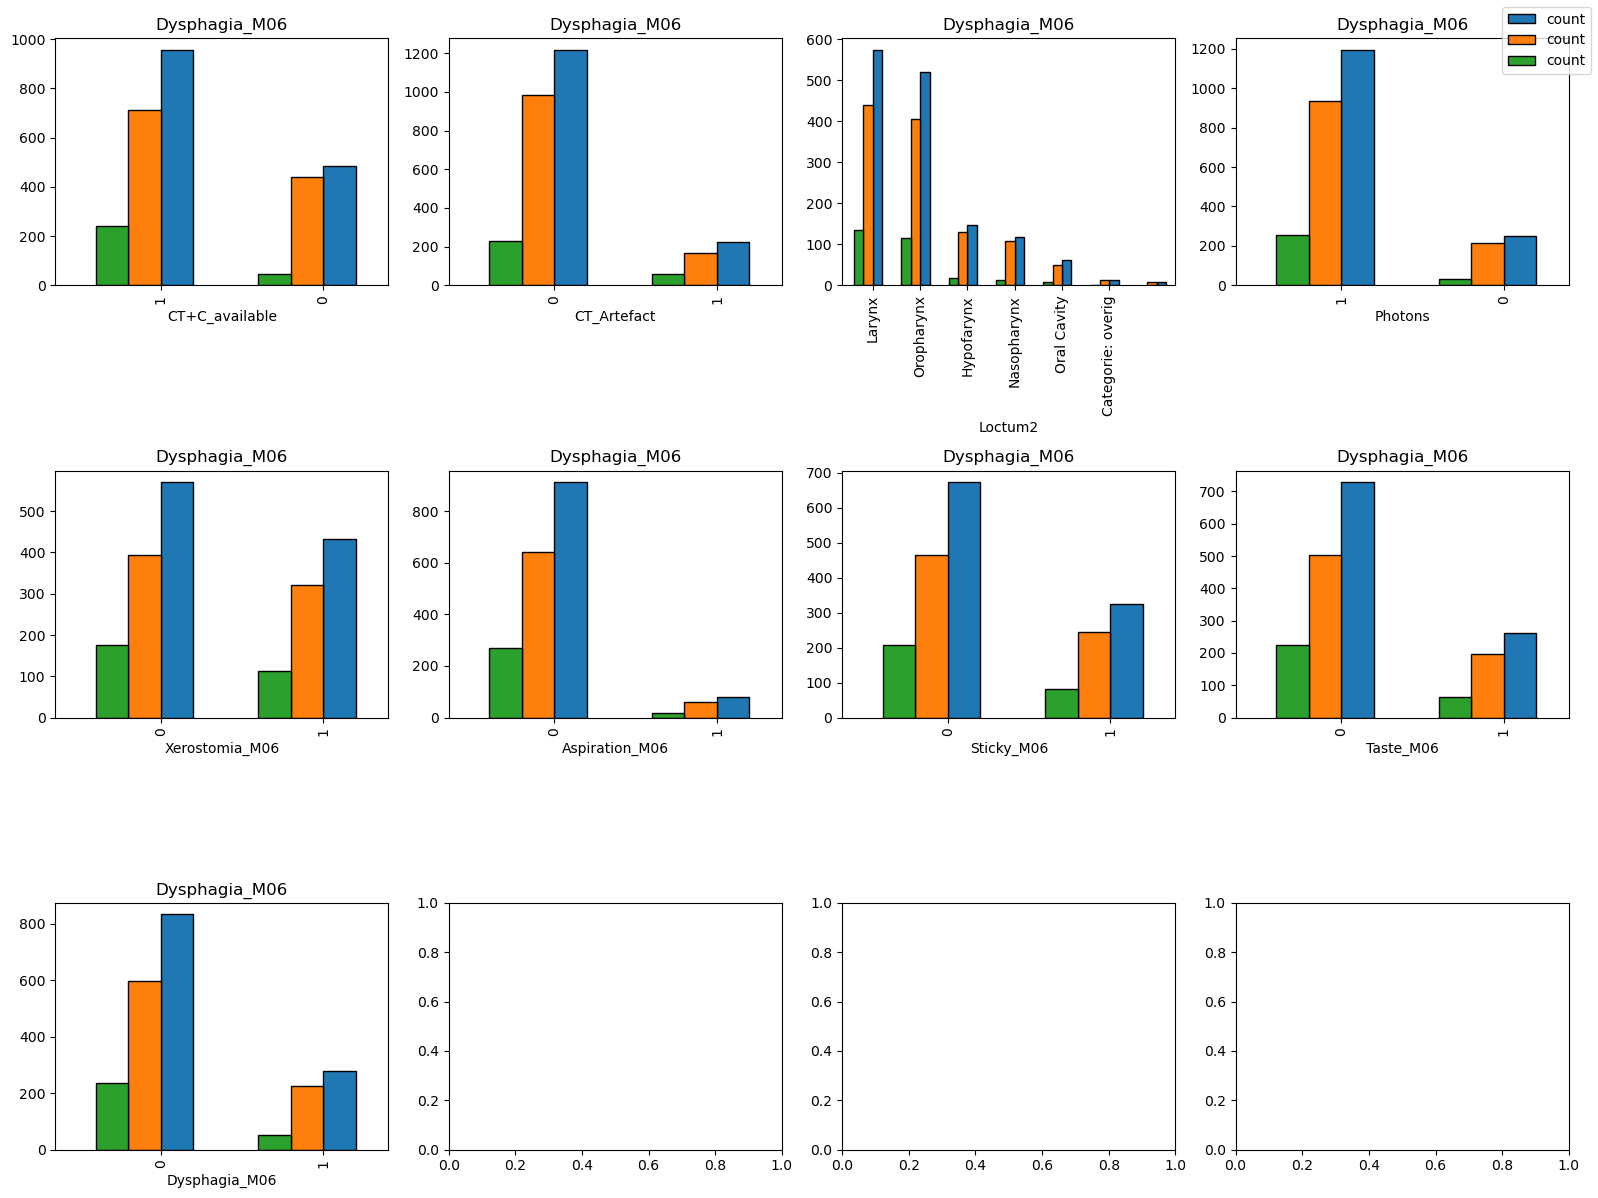

In [51]:
"""
df1 = df_dataset
df2 = df_train_val
df3 = df_test


#fig, axs = plt.subplots(1, len(df1.columns), figsize=(15, 5))


stratified_sampling_columns = config.strata_groups


#df_summary_statistics = pd.DataFrame(columns=["feature", "total_dataset", "training_datset", "testing_dataset"])

cols = 4
rows = math.ceil(len(stratified_sampling_columns) / cols)
bar_width = 0.2
normalise = False

fig,ax = plt.subplots(rows,cols,figsize=[4*cols,4*rows])
for i in range(len(stratified_sampling_columns)):
    column = stratified_sampling_columns[i]
    [row_idx, col_idx] = [int(i/cols),int(i % cols)]

    ax[row_idx, col_idx].set_title(col_name)

    max_keys = 0
# Plot value counts for each DataFrame and each column
#for i, column in enumerate(df1.columns):
    for j, df in enumerate([df1, df2, df3]):
        value_counts = df[column].value_counts()

        if len(value_counts) > max_keys:
            max_keys = len(value_counts)

        #.plot(kind='bar', ax=ax[row_idx, col_idx], color='g', align='edge', width=bar_width, label="Train_Val")

        value_counts.plot(kind='bar', ax=ax[row_idx, col_idx], color=f'C{j}', edgecolor='black', position=j, width=bar_width)

        ax[row_idx, col_idx].axis(xmax=max_keys-1 + 2*bar_width)
        

    #axs[i].set_title(f'Column: {column}')
    #ax[i].set_xlabel('Values')
    #ax[i].set_ylabel('Count')

handles, labels = ax[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

# Adjust layout
plt.tight_layout()
plt.show()

"""

In [17]:
### write into one output file

column_name = 'Split'
column_position = 1  # 0-indexed position

df_train_val[column_name] = "train_val"
df_test[column_name] = "test"

# Use the insert method to make it the second column

df = pd.concat([df_train_val, df_test])

df.insert(column_position, column_name, df.pop(column_name))
df.insert(column_position, column_name, df.pop(column_name))


df = df.sort_values(by=['PatientID'])
df.to_excel('play.xlsx', index=None)

df.head(10)

,PatientID,Split,Sex,Age,CT+C_available,CT_Artefact,Loctum2,Photons,Xerostomia_W01,Aspiration_W01,...,Taste_M18_little,Taste_M18_moderate,Taste_M18_not_at_all,Taste_M18_severe,Dysphagia_M06_no,Dysphagia_M06_yes,Dysphagia_M12_no,Dysphagia_M12_yes,Dysphagia_M18_no,Dysphagia_M18_yes
142,0005680,test,1,0.68,1,0,Larynx,1,0.0,0.0,...,0,0,1,0,1,0,1,0,1,0
892,0020715,test,1,0.56,1,0,Oropharynx,1,0.0,0.0,...,1,0,0,0,1,0,1,0,1,0
143,0021879,test,1,0.67,1,0,Oropharynx,1,0.0,0.0,...,1,0,0,0,1,0,0,1,0,1
144,0049714,train_val,1,0.60,0,0,Larynx,1,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
145,0052277,train_val,1,0.50,1,0,Oropharynx,1,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
893,0059896,test,1,0.51,1,0,Oropharynx,1,0.0,0.0,...,1,0,0,0,1,0,1,0,1,0
146,0064747,test,1,0.77,0,0,Larynx,1,0.0,0.0,...,0,0,1,0,1,0,1,0,1,0
147,0066593,train_val,1,0.54,1,0,Oropharynx,1,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
148,0070426,train_val,1,0.75,1,0,Oropharynx,1,0.0,0.0,...,1,0,0,0,1,0,0,1,0,1
149,0079378,train_val,1,0.68,1,0,Oropharynx,1,0.0,0.0,...,0,0,0,0,1,0,1,0,1,0
